In [1]:
import os
os.chdir(r"C:\Users\Lenovo\Desktop\KYC_Project")
print("Working directory:", os.getcwd())

Working directory: C:\Users\Lenovo\Desktop\KYC_Project


In [2]:
import cv2
import numpy as np
from PIL import Image, ImageChops, ImageEnhance
import io
import matplotlib.pyplot as plt

print("All imports successful")

All imports successful


In [3]:
def generate_ela(image_path, quality=90):
    """
    Generate Error Level Analysis image.
    Steps:
    1. Open original image
    2. Resave it as JPEG at given quality
    3. Find pixel difference between original and resaved
    4. Amplify the difference so it's visible
    """
    # Open original
    original = Image.open(image_path).convert("RGB")

    # Resave to memory buffer at reduced quality
    buffer = io.BytesIO()
    original.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    resaved = Image.open(buffer).convert("RGB")

    # Find difference
    ela_image = ImageChops.difference(original, resaved)

    # Amplify so small differences become visible
    extrema = ela_image.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1
    scale = 255.0 / max_diff
    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)

    return ela_image

print("ELA function ready")

ELA function ready


Testing on: valid\images\Data Set 14_front-nagarikta_aug1_noisy_jpg.rf.uqWgti2NqpVXPxUyfR46.jpg


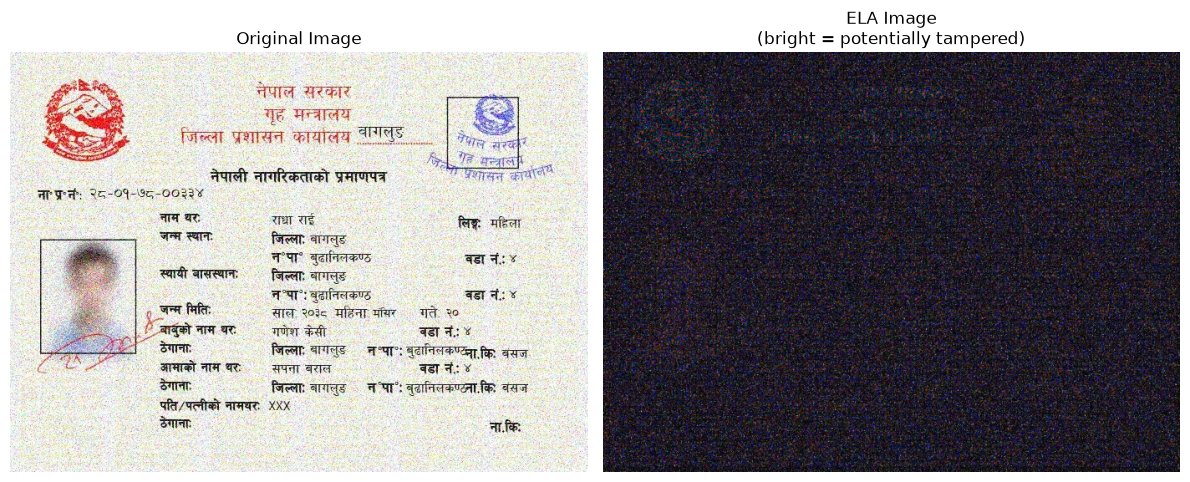

In [4]:
# Test on a valid image
test_image = os.path.join("valid", "images", os.listdir("valid/images")[0])
print("Testing on:", test_image)

ela = generate_ela(test_image)

# Show original and ELA side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(Image.open(test_image))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(ela)
axes[1].set_title("ELA Image\n(bright = potentially tampered)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [5]:
def analyze_ela(image_path, quality=90, threshold=0.4):
    """
    Analyze ELA image and return tampering score.
    
    Genuine doc  → dark uniform ELA → low score → is_genuine True
    Tampered doc → bright spots ELA → high score → is_genuine False
    """
    ela = generate_ela(image_path, quality)
    ela_array = np.array(ela).astype(np.float32)

    # Metric 1 — mean brightness (higher = more suspicious)
    mean_val = ela_array.mean() / 255.0

    # Metric 2 — std deviation (higher variance = more suspicious)
    std_val = ela_array.std() / 255.0

    # Metric 3 — percentage of very bright pixels (> 200)
    bright_pixels = (ela_array > 200).sum()
    total_pixels = ela_array.size
    bright_ratio = bright_pixels / total_pixels

    # Metric 4 — max value in ELA
    max_val = ela_array.max() / 255.0

    # Combine into suspicion score (higher = more tampered)
    suspicion_score = (
        mean_val * 0.3 +
        std_val  * 0.3 +
        bright_ratio * 0.2 +
        max_val  * 0.2
    )

    # Genuineness = inverse of suspicion
    genuine_score = round(1.0 - suspicion_score, 4)
    is_genuine = genuine_score >= threshold

    return {
        "is_genuine": is_genuine,
        "genuine_score": genuine_score,
        "suspicion_score": round(suspicion_score, 4),
        "ela_mean": round(mean_val, 4),
        "ela_std": round(std_val, 4),
        "bright_ratio": round(bright_ratio, 4),
        "ela_max": round(max_val, 4),
    }

print("analyze_ela function ready")

analyze_ela function ready


In [6]:
valid_images = os.listdir("valid/images")

for fname in valid_images[:5]:
    img_path = os.path.join("valid", "images", fname)
    result = analyze_ela(img_path)

    print(f"{fname[:45]}")
    print(f"  Genuine: {result['is_genuine']}  score: {result['genuine_score']}")
    print(f"  Suspicion: {result['suspicion_score']}  mean: {result['ela_mean']}  std: {result['ela_std']}")
    print()

Data Set 14_front-nagarikta_aug1_noisy_jpg.rf
  Genuine: True  score: 0.7296
  Suspicion: 0.2704  mean: 0.1281999945640564  std: 0.10639999806880951

Data Set 14_front-nagarikta_aug2_phone_tilt_j
  Genuine: True  score: 0.7618
  Suspicion: 0.2382  mean: 0.05649999901652336  std: 0.07090000063180923

Data Set 14_front-nagarikta_aug3_blur_jpg.rf.
  Genuine: True  score: 0.7619
  Suspicion: 0.2381  mean: 0.055799998342990875  std: 0.07109999656677246

Data Set 14_front-nagarikta_jpg.rf.leBP6qMYjp
  Genuine: True  score: 0.7768
  Suspicion: 0.2232  mean: 0.027499999850988388  std: 0.04989999905228615

Data Set 15_front-nagarikta_aug1_noisy_jpg.rf
  Genuine: True  score: 0.7336
  Suspicion: 0.2664  mean: 0.12030000239610672  std: 0.10100000351667404



In [7]:
os.makedirs("ml/tampering", exist_ok=True)

summary = """
Tampering Detection Module
---------------------------
Method: Error Level Analysis (ELA)
Threshold: 0.4 (genuine_score >= 0.4 = genuine)

How it works:
  1. Resave image as JPEG at quality=90
  2. Find pixel difference between original and resaved
  3. Amplify differences
  4. Analyze brightness metrics of ELA image

Metrics used:
  ela_mean    (weight 0.3) — overall brightness
  ela_std     (weight 0.3) — variance in brightness
  bright_ratio(weight 0.2) — % of very bright pixels
  ela_max     (weight 0.2) — maximum brightness

Score interpretation:
  genuine_score > 0.4 → Genuine document
  genuine_score < 0.4 → Possibly tampered

Functions:
  generate_ela(image_path, quality=90)  -> PIL Image
  analyze_ela(image_path)               -> dict
"""

with open("ml/tampering/tampering_summary.txt", "w") as f:
    f.write(summary)

print("Module saved")
print(summary)

UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 600: character maps to <undefined>

In [8]:
with open("ml/tampering/tampering_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary)

print("Module saved")
print(summary)

Module saved

Tampering Detection Module
---------------------------
Method: Error Level Analysis (ELA)
Threshold: 0.4 (genuine_score >= 0.4 = genuine)

How it works:
  1. Resave image as JPEG at quality=90
  2. Find pixel difference between original and resaved
  3. Amplify differences
  4. Analyze brightness metrics of ELA image

Metrics used:
  ela_mean    (weight 0.3) — overall brightness
  ela_std     (weight 0.3) — variance in brightness
  bright_ratio(weight 0.2) — % of very bright pixels
  ela_max     (weight 0.2) — maximum brightness

Score interpretation:
  genuine_score > 0.4 → Genuine document
  genuine_score < 0.4 → Possibly tampered

Functions:
  generate_ela(image_path, quality=90)  -> PIL Image
  analyze_ela(image_path)               -> dict

